In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from scipy.fft import fft, fftfreq
from scipy.stats import kurtosis, skew


BASE_PATH = "dataset/CSV Files"
CLASSES = ["Normal", "Inner Race Fault", "Outer Race Fault"]
SAMPLING_RATE = 1000  # 1000 Hz

# Plotting Styles
COLORS = {"Normal": "green", "Inner Race Fault": "red",
          "Outer Race Fault": "orange"}
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

Helper function to visualise a single random csv


In [ ]:
def load_sample_file(class_name, specific_index=None):
    """
    Loads a file and calculates the Vector Sum (Total Magnitude).
    Returns: The combined 1D signal array.
    """
    folder_path = os.path.join(BASE_PATH, class_name)

    # Use Natural Sorting (to handle 'File(10)' vs 'File(2)' correctly)
    try:
        files = sorted(glob.glob(os.path.join(folder_path, "*.csv")),
                       key=lambda x: int(x.split('(')[1].split(')')[0]))
    except:
        # Fallback if filename format is different
        files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

    if not files:
        print(f"Warning: No files found in {folder_path}")
        return None

    # Pick specific index or random
    if specific_index is not None:
        idx = specific_index % len(files)
    else:
        import random
        idx = random.randint(0, len(files)-1)

    filepath = files[idx]
    print(f"Loading {class_name}: {os.path.basename(filepath)}")

    # Read CSV
    try:
        df = pd.read_csv(filepath, header=None)

        # Calculate Vector Sum (Magnitude)
        # cols 0,1,2 are X, Y, Z
        x = df.iloc[:, 0].values
        y = df.iloc[:, 1].values
        z = df.iloc[:, 2].values
        # The "Root Sum Square" gives total vibration energy
        signal = np.sqrt(x**2 + y**2 + z**2)
        

        return signal

    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

Loading Normal: XYZ_N(117).csv
Loading Inner Race Fault: XYZ_IR(117).csv
Loading Outer Race Fault: XYZ_OR(117).csv


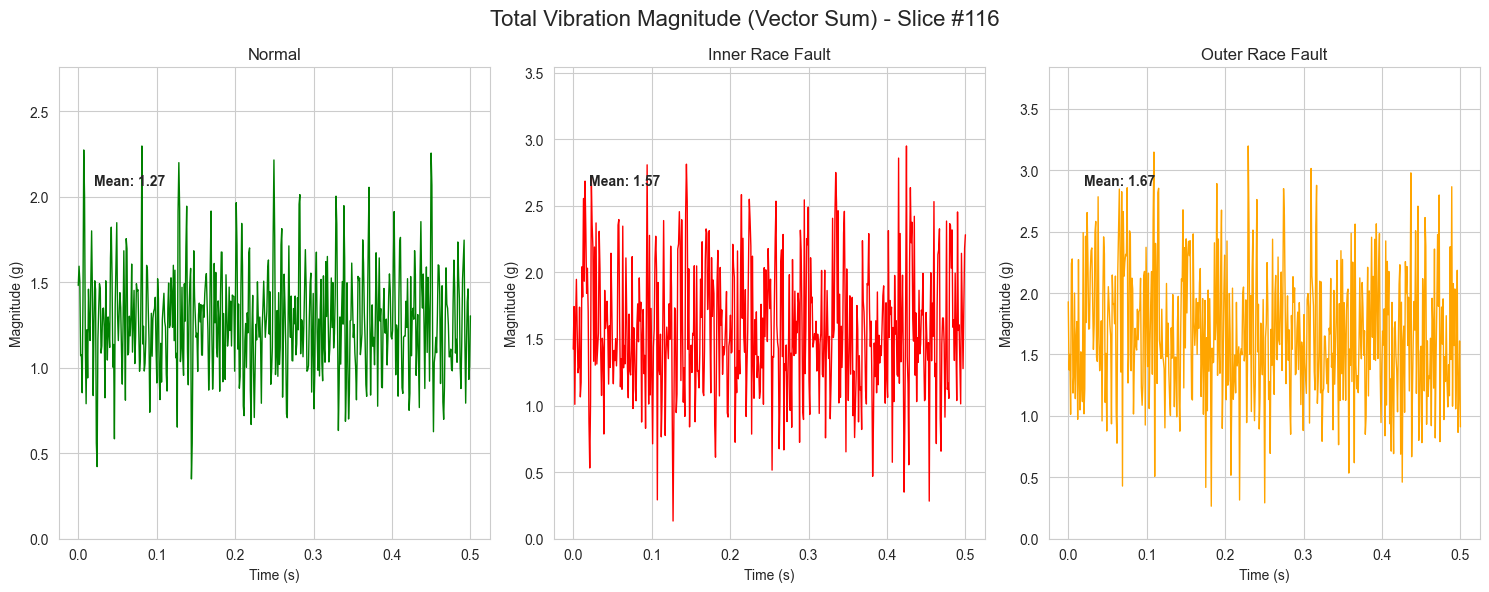

In [ ]:
# Pick a random index to compare the SAME time slice across classes
RANDOM_IDX = np.random.randint(0, 500)

plt.figure()
plt.suptitle(
    f"Total Vibration Magnitude (Vector Sum) - Slice #{RANDOM_IDX}", fontsize=16)

for i, class_name in enumerate(CLASSES):
    signal = load_sample_file(class_name, specific_index=RANDOM_IDX)
    if signal is None:
        continue

    # Take first 0.5 seconds (500 samples)
    t = np.linspace(0, 0.5, 500)
    signal_snippet = signal[:500]

    plt.subplot(1, 3, i+1)
    plt.plot(t, signal_snippet, color=COLORS[class_name], lw=1)
    plt.title(class_name)
    plt.xlabel("Time (s)")
    plt.ylabel("Magnitude (g)")

    # Force Y-axis to start at 0 since Vector Sum is always positive
    plt.ylim(0, np.max(signal_snippet)*1.2)

    # Annotate Mean Amplitude
    mean_val = np.mean(signal_snippet)
    plt.text(0.02, max(signal_snippet)*0.9,
             f"Mean: {mean_val:.2f}", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Loading Normal: XYZ_N(169).csv
Loading Inner Race Fault: XYZ_IR(169).csv
Loading Outer Race Fault: XYZ_OR(169).csv


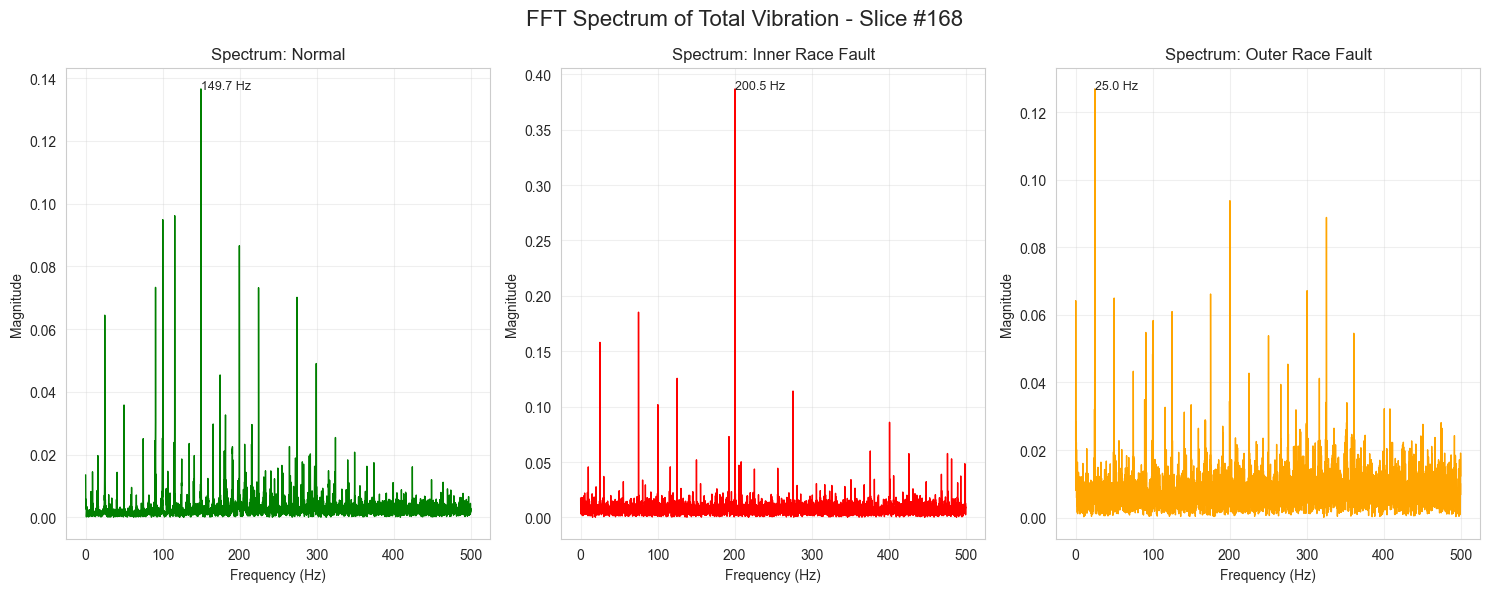

In [ ]:
# RANDOM_IDX = np.random.randint(0, 500)

plt.figure()
plt.suptitle(
    f"FFT Spectrum of Total Vibration - Slice #{RANDOM_IDX}", fontsize=16)

for i, class_name in enumerate(CLASSES):
    signal = load_sample_file(class_name, specific_index=RANDOM_IDX)
    if signal is None:
        continue

    # Remove DC Offset (Gravity)
    # Vector sum includes constant 1g (gravity). We subtract mean to center at 0 for FFT.
    signal = signal - np.mean(signal)

    # Perform FFT
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, 1 / SAMPLING_RATE)

    # Get positive frequencies (0 - 500Hz)
    idx = np.where((xf > 0) & (xf < 500))
    freqs = xf[idx]
    amps = np.abs(yf[idx])

    # Normalize
    amps = amps * 2 / N

    plt.subplot(1, 3, i+1)
    plt.plot(freqs, amps, color=COLORS[class_name], lw=1)
    plt.title(f"Spectrum: {class_name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, alpha=0.3)

    # Highlight top peak
    peak_idx = np.argmax(amps)
    plt.text(freqs[peak_idx], amps[peak_idx],
             f"{freqs[peak_idx]:.1f} Hz", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
stats_data = []
print("Processing all files with Vector Sum logic...")

for class_name in CLASSES:
    folder_path = os.path.join(BASE_PATH, class_name)
    files = glob.glob(os.path.join(folder_path, "*.csv"))

    # Limit to 500 files per class for speed 
    # files = files[:500]

    print(f"  - Processing {len(files)} files in {class_name}...")

    for file in files:
        try:
            df = pd.read_csv(file, header=None)

            # Vector Sum Calculation
            if df.shape[1] >= 3:
                x = df.iloc[:, 0].values
                y = df.iloc[:, 1].values
                z = df.iloc[:, 2].values
                sig = np.sqrt(x**2 + y**2 + z**2)
            else:
                sig = df.iloc[:, 0].values

            # Features
            # RMS represents total energy
            rms = np.sqrt(np.mean(sig**2))

            # Kurtosis (Spikiness)
            kurt = kurtosis(sig)

            # Peak-to-Peak (Max range)
            p2p = np.max(sig) - np.min(sig)

            stats_data.append({
                "Class": class_name,
                "RMS_Energy": rms,
                "Kurtosis": kurt,
                "Peak2Peak": p2p
            })

        except Exception as e:
            continue

stats_df = pd.DataFrame(stats_data)
print("Feature extraction complete.")
stats_df.head()

Processing all files with Vector Sum logic...
  - Processing 2160 files in Normal...
  - Processing 2160 files in Inner Race Fault...
  - Processing 2160 files in Outer Race Fault...
Feature extraction complete.


,Class,RMS_Energy,Kurtosis,Peak2Peak
0,Normal,1.284409,0.006425,2.095525
1,Normal,1.166548,-0.147890,1.743811
2,Normal,1.265966,-0.157286,2.088985
3,Normal,1.318603,0.017793,2.218491
4,Normal,1.303926,0.071991,2.320863


/var/folders/km/cm3h569x1h75xfrn37h18xcc0000gn/T/ipykernel_11447/1610026893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="RMS_Energy", data=stats_df, palette=COLORS)
/var/folders/km/cm3h569x1h75xfrn37h18xcc0000gn/T/ipykernel_11447/1610026893.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="Kurtosis", data=stats_df, palette=COLORS)


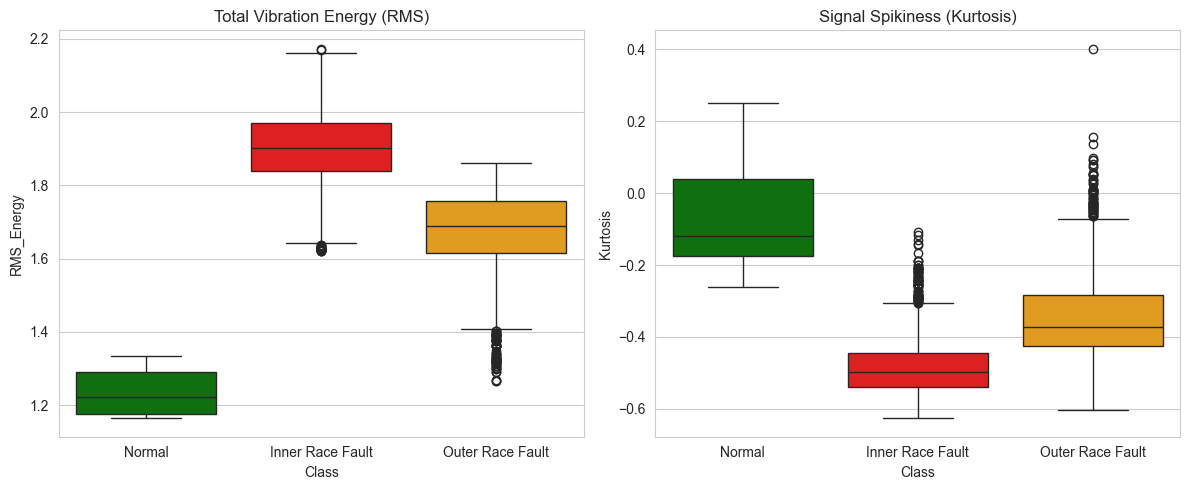

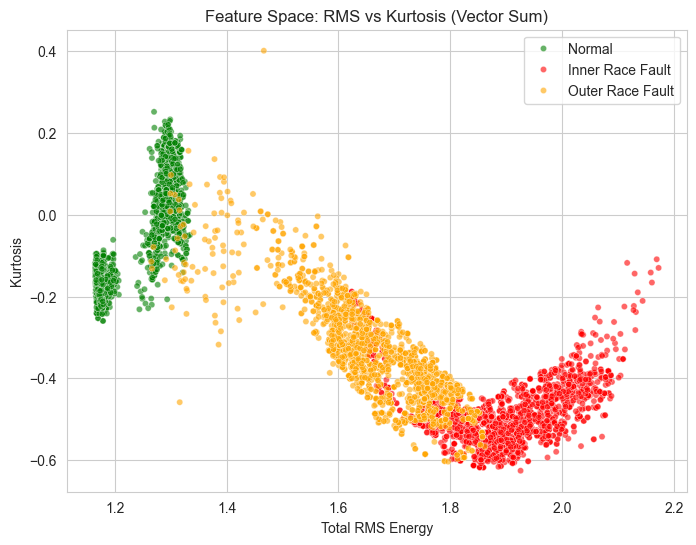

In [ ]:
# Boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x="Class", y="RMS_Energy", data=stats_df, palette=COLORS)
plt.title("Total Vibration Energy (RMS)")

plt.subplot(1, 2, 2)
sns.boxplot(x="Class", y="Kurtosis", data=stats_df, palette=COLORS)
plt.title("Signal Spikiness (Kurtosis)")

plt.tight_layout()
plt.show()

# Scatter Plot (Clustering)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=stats_df,
    x="RMS_Energy",
    y="Kurtosis",
    hue="Class",
    palette=COLORS,
    alpha=0.6,
    s=20
)
plt.title("Feature Space: RMS vs Kurtosis (Vector Sum)")
plt.xlabel("Total RMS Energy")
plt.ylabel("Kurtosis")
plt.legend()
plt.show()